<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>Regularization</h1>
<p>Regularization is a method that penalizes the model for memorizing. Without it there is a risk that the model does not learn the features, it just memorizes the specific examples.<br>Thus it helps the model generalize, in some cases it decreases accuracy in exchange. Regularization also tends to decrease training time.
<br>For relatively small models regularization can actually hurt the model's performance, but for large and sufficiently complex data it is recommended.</p>

<p>Types of regularization: <ul>
<li>Node regularization: Modify the model (dropout)</li>
<li>Loss regularization: Add cost to the loss function (L1/L2 regularization)</li>
<li>Data regularization: Modify the data (batch training, data augmentation, normalization)</li>
</ul></p>

<p>Dropout refers to randomly removing nodes for the interval of one epoch during the training. This is implemented by having their activation function return 0.</p>
<p>L1/L2 regularizer refers to modifying the loss function by adding "something" to it. This prevents the weights from becoming too large.</p>
<p>Data regularization refers to modifying data to generalize better.</p>

<p>The "best" technique is problem-specific, it is hard to know beforehand.</p>

<h2>train() and eval() mode</h2>
<p>The gradients are calculated only during backpropagation, not during model evaluation. Some regularization technics are applied only during training, not evaluation. This means we need to be able to deactivate gradient computing and regularization during the evaluation of model performance. Switching the model between training mode and evaluation mode allows that.<br>model.train() switches it into training mode - Regularization active<br>model.eval() switches it into testing mode - Regularization inactive<br>torch.no_grad() is used in testing - Gradient computing inactive<br></p><p>train() is set by default, necessary for training. eval() is necessary when evaluation regularized models.  no_grad() is never necessary, but makes models evaluate faster.</p>

<h2>Dropout regularization</h2>
<p>Dropout regularization usually has a parameter which is the probability of dropout. The randomly selected models will output 0 in the given training epoch. Dropout only applies to training, during testing we don't apply any dropout. This creates a problem: During test we get higher values because all nodes are contributing to the output. One solution is multiplying every weight with (1-p) during test. Another solution is the reverse of this, dividing the weights by (1-p) during training. Pytorch implements the second method.</p>
<p>Dropout regularization has multiple effects: <ul>
<li>Prevents any single node from learning too much</li>
<li>Forces the model to have a more distributed representation</li>
<li>Makes the model less reliant on individual nodes, and so moren stable</li>
</ul>
Other observations:
<ul>
<li>Generally makes the model require more training, but epochs are faster.</li>
<li>Can reduce accuracy, but increases generalizability.</li>
<li>Usually works better on deep networks, than on shallow ones.</li>
</ul></p>
</div>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

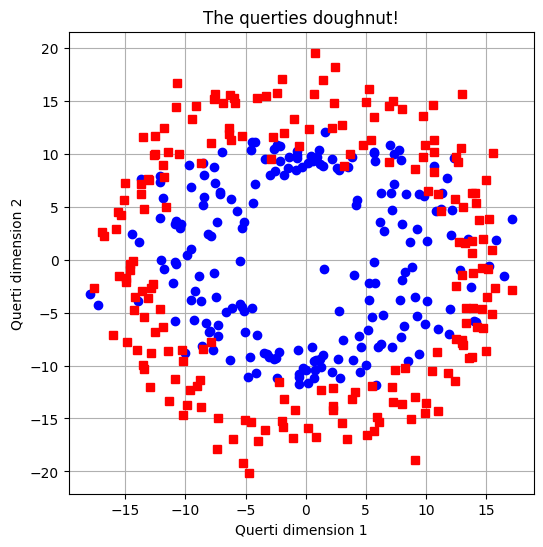

In [2]:
nPerCluster = 200

th = np.linspace(0, 4*np.pi, nPerCluster)
r1 = 10
r2 = 15

a = [
    r1 * np.cos(th) + np.random.randn(nPerCluster)*3,
    r1 * np.sin(th) + np.random.randn(nPerCluster)
]

b = [
    r2 * np.cos(th) + np.random.randn(nPerCluster),
    r2 * np.sin(th) + np.random.randn(nPerCluster)*3
]

data_np = np.hstack((a, b)).T
labels_np = np.vstack((np.zeros((nPerCluster, 1)), np.ones((nPerCluster, 1))))

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

fig = plt.figure(figsize=(6, 6))

plt.plot(data[np.where(labels == 0)[0]][:,0], data[np.where(labels == 0)[0]][:,1], 'bo')
plt.plot(data[np.where(labels == 1)[0]][:,0], data[np.where(labels == 1)[0]][:,1], 'rs')
plt.title('The querties doughnut!')
plt.xlabel('Querti dimension 1')
plt.ylabel('Querti dimension 2')
plt.grid()
plt.show()

In [3]:
trainData, testData, trainLabels, testLabels = train_test_split(data, labels, test_size=0.2)

trainData = TensorDataset(trainData, trainLabels)
testData = TensorDataset(testData, testLabels)

batchSize = 16
trainLoader = DataLoader(trainData, batch_size=batchSize, shuffle=True)
testLoader = DataLoader(testData, batch_size=testData.tensors[0].shape[0])

In [4]:
class ModelClass(nn.Module):
    def __init__(self, dropoutRate):
        super().__init__()

        self.input = nn.Linear(2, 128)
        self.hidden = nn.Linear(128, 128)
        self.output = nn.Linear(128, 1)

        self.dr = dropoutRate # dropout-rate
    
    def forward(self, x):
        x = F.relu(self.input(x))
        x = F.dropout(x, p=self.dr, training=self.training)
        x = F.relu(self.hidden(x))
        x = F.dropout(x, p=self.dr, training=self.training)
        x = self.output(x)
        return x

def createModel(dropoutRate):
    model = ModelClass(dropoutRate)
    lossFunction = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(params=model.parameters(), lr=0.002)
    return model, lossFunction, optimizer

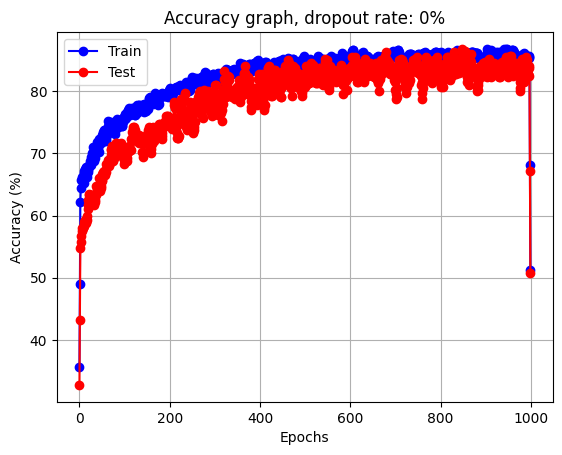

In [5]:
numberOfEpochs = 1_000
dropoutRate = 0
model, lossFunction, optimizer = createModel(dropoutRate)

trainAccuracy = []
testAccuracy = []

for i in range(numberOfEpochs):
    batchAccuracy = []

    model.train()
    for x,y in trainLoader:
        yHat = model(x)
        loss = lossFunction(yHat, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batchAccuracy.append(100 * torch.mean(((yHat>0.5)==y).float()))
    
    trainAccuracy.append(np.mean(batchAccuracy))
    model.eval()
    X,Y = next(iter(testLoader))
    yHat = model(X)
    testAccuracy.append(100 * torch.mean(((yHat>0.5)==Y).float()))

def smooth(x, k):
    return np.convolve(x, np.ones(k)/k, mode='same')

plt.plot(smooth(trainAccuracy, 5), 'bo-')
plt.plot(smooth(testAccuracy, 5), 'ro-')
plt.grid()
plt.legend(['Train', 'Test'])
plt.title(f'Accuracy graph, dropout rate: {dropoutRate*100}%')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

In [6]:
dropoutRates = np.arange(0, 10) / 10
results = np.zeros((len(dropoutRates), 2))

for index,dropoutRate in enumerate(dropoutRates):
    model, lossFunction, optimizer = createModel(dropoutRate)

    trainAccuracy = []
    testAccuracy = []

    for i in range(numberOfEpochs):
        batchAccuracy = []

        model.train()
        for x,y in trainLoader:
            yHat = model(x)
            loss = lossFunction(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchAccuracy.append(100 * torch.mean(((yHat>0.5)==y).float()))
    
        trainAccuracy.append(np.mean(batchAccuracy))
        model.eval()
        X,Y = next(iter(testLoader))
        yHat = model(X)
        testAccuracy.append(100 * torch.mean(((yHat>0.5)==Y).float()))

    results[index][0] = np.mean(trainAccuracy[-100:])
    results[index][1] = np.mean(testAccuracy[-100:])

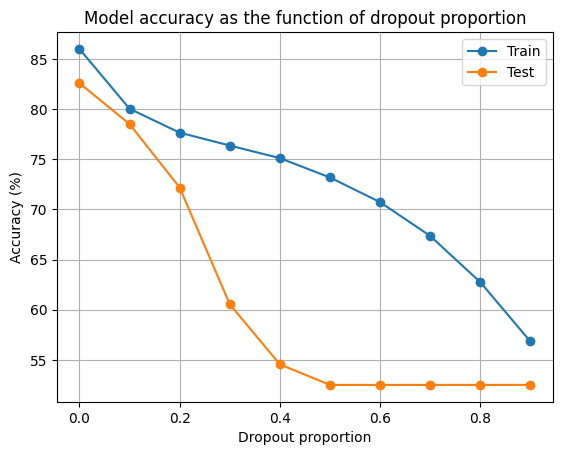

In [7]:
plt.plot(dropoutRates, results, 'o-')
plt.xlabel('Dropout proportion')
plt.ylabel('Accuracy (%)')
plt.legend(['Train', 'Test'])
plt.title('Model accuracy as the function of dropout proportion')
plt.grid()
plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>L1 and L2 regularization</h2>
<p>When applying L1 or L2 regularizations we add a plus term to the cost function (the sum of the loss function throughout the dataset). </p>

L1 regularization creates sparsity by setting some weights to 0: $$ \mathcal J = \frac{1}{n}\sum_{i=1}^{n}\mathcal L(\hat{y}_i, y_i) + \lambda||w|| $$

L2 regularization shrinks all weights, especially large weights: $$ \mathcal J = \frac{1}{n}\sum_{i=1}^{n}\mathcal L(\hat{y}_i, y_i) + \lambda||w||^2_2 $$

<p>We also need to minimize the added term, so this prevents the weights from becoming too large. The lambda is a parameter, it is called the regularization parameter.</p>

</div>

In [ ]:
def createNewModelL2(l2Lambda):
    '''
    L2 example. (l2Lambda: float)
    '''
    model = nn.Sequential(
        nn.Linear(4, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 3)
    )

    lossFunction = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=.005, weight_decay=l2Lambda)

    return model, lossFunction, optimizer


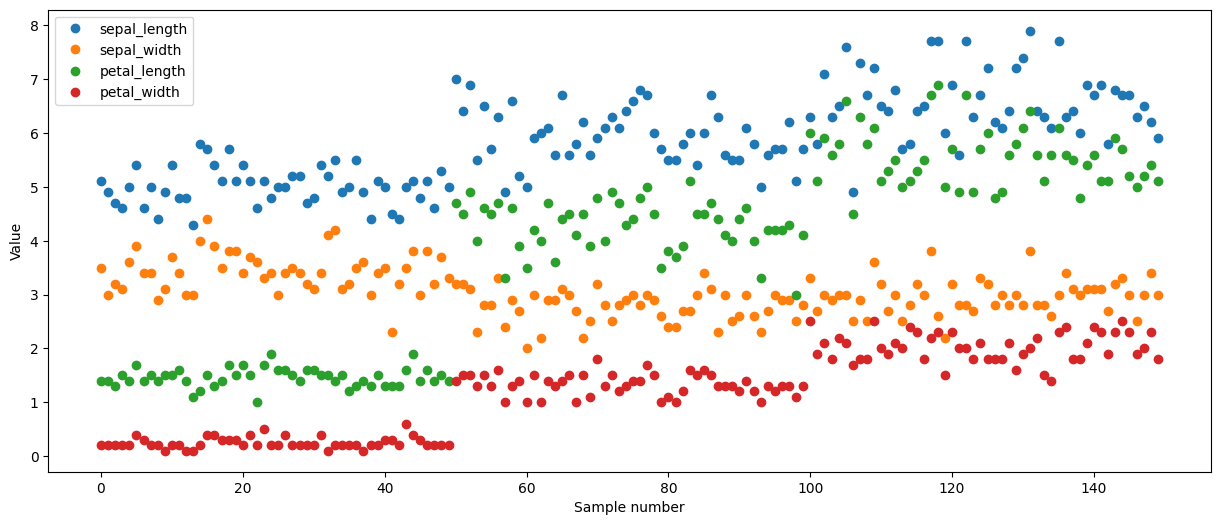

In [4]:
import seaborn as sns
iris = sns.load_dataset('iris')

iris.plot(marker='o', linestyle='none', figsize=(15, 6))
plt.xlabel('Sample number')
plt.ylabel('Value')
plt.show()

In [ ]:
data = torch.tensor(iris[iris.columns[0:4]].values).float()
labels = torch.zeros(data.shape[0])

species = iris[iris.columns[4]]
uniqueLabels = np.unique(iris[iris.columns[4]])

index = 0
for label in uniqueLabels:
    labels[np.where(species == label)] = index
    index += 1

trainData, testData, trainLabels, testLabels = train_test_split(data, labels, test_size=0.2)
trainData = TensorDataset(trainData, trainLabels)
testData = TensorDataset(testData, testLabels)

batchSize = 16
trainLoader = DataLoader(trainData, batch_size=batchSize, shuffle=True)
testLoader = DataLoader(testData, batch_size=testData.tensors[0].shape[0], shuffle=True)

In [29]:
trainLoader = DataLoader(trainData, batch_size=batchSize, shuffle=True)
for x,y in trainLoader:
    print(x.shape, y.shape)
print('')

trainLoader = DataLoader(trainData, batch_size=batchSize, shuffle=True, drop_last=True) # drop_last=True will cause the DataLoader to drop the last batch if it is not whole
for x,y in trainLoader:
    print(x.shape, y.shape)

trainLoader = DataLoader(trainData, batch_size=batchSize, shuffle=True)

torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([8, 4]) torch.Size([8])

torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
